In [ ]:
import numpy as np
import pandas as pd
import tkinter as tk
from tkinter import messagebox, filedialog
from tkinter import ttk
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Global dataset variable
data = None
model = None
def load_dataset():
    global data
    file_path = filedialog.askopenfilename(filetypes=[("CSV Files", "*.csv")])
    if file_path:
        try:
            data = pd.read_csv(file_path)
            data.columns = data.columns.str.strip()
            update_table(data)
            messagebox.showinfo("Success", "Dataset loaded successfully!")
        except Exception as e:
            messagebox.showerror("Error", f"Failed to load file: {e}")

def train_model():
    global model, data
    if data is None:
        messagebox.showerror("Error", "Please load a dataset first!")
        return
    try:
        data.columns = data.columns.str.strip()
        expected_columns = ['Login_attempts', 'IP_address', 'Failed_logins', 'Threat']
        missing_cols = [col for col in expected_columns if col not in data.columns]
        if missing_cols:
            messagebox.showerror("Error", f"Dataset is missing required columns: {', '.join(missing_cols)}")
            return
        
        X = data[['Login_attempts', 'IP_address', 'Failed_logins']].copy()
        y = data['Threat'].copy()
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        model = RandomForestClassifier(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        accuracy_label.config(text=f"Accuracy: {acc:.2f}")
        messagebox.showinfo("Training Complete", f"Model trained with accuracy: {acc:.2f}")
        plot_graph(y_test, y_pred)
    except Exception as e:
        messagebox.showerror("Training Error", f"An error occurred during training: {e}")

def plot_graph(y_test, y_pred):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.hist([y_test, y_pred], label=["Actual", "Predicted"], alpha=0.7, bins=3)
    ax.set_xlabel("Threat Status")
    ax.set_ylabel("Count")
    ax.legend()
    ax.set_title("Actual vs Predicted Threat Profiling")
    
    for widget in graph_frame.winfo_children(): 
        widget.destroy()
    canvas = FigureCanvasTkAgg(fig, master=graph_frame)
    canvas.draw()
    canvas.get_tk_widget().pack()

def predict_event():
    global model
    if model is None:
        messagebox.showerror("Error", "Please train the model first!")
        return
    try:
        feature1 = float(feature1_entry.get())
        feature2 = float(feature2_entry.get())
        feature3 = float(feature3_entry.get())
        input_features = np.array([[feature1, feature2, feature3]])
        prediction = model.predict(input_features)
        result = "Cybersecurity Threat Detected" if prediction[0] == 1 else "No Threat Detected"
        prediction_label.config(text=f"Prediction: {result}")
    except ValueError:
        messagebox.showerror("Input Error", "Please enter valid numerical values.")

def update_table(data):
    for row in tree.get_children():
        tree.delete(row)
    for _, row in data.iterrows():
        tree.insert("", "end", values=list(row))

# Creating GUI
root = tk.Tk()
root.title("EVENT PROFILE-DRIVEN ANN FOR IDENTIFYING CYBER SECURITY THREAT")
root.geometry("800x700")
root.configure(bg="#2E3B55")

title_label = tk.Label(root, text="EVENT PROFILE-DRIVEN ANN FOR IDENTIFYING CYBER SECURITY THREAT", font=("Arial", 16, "bold"), bg="#2E3B55", fg="white")
title_label.pack(pady=10)

button_style = {"bg": "#4CAF50", "fg": "white", "font": ("Arial", 12)}
tk.Button(root, text="Load Dataset", command=load_dataset, **button_style).pack()
tk.Button(root, text="Train Model", command=train_model, **button_style).pack()
accuracy_label = tk.Label(root, text="Accuracy: ", bg="#2E3B55", fg="white")
accuracy_label.pack()

columns = ("Login_attempts", "IP_address", "Failed_logins", "Threat")
tree = ttk.Treeview(root, columns=columns, show="headings", height=5)
for col in columns:
    tree.heading(col, text=col)
    tree.column(col, width=80)
tree.pack(pady=10)

tk.Label(root, text="Login_attempts:", bg="#2E3B55", fg="white").pack()
feature1_entry = tk.Entry(root)
feature1_entry.pack()
tk.Label(root, text="IP_address:", bg="#2E3B55", fg="white").pack()
feature2_entry = tk.Entry(root)
feature2_entry.pack()
tk.Label(root, text="Failed_logins:", bg="#2E3B55", fg="white").pack()
feature3_entry = tk.Entry(root)
feature3_entry.pack()

tk.Button(root, text="Predict Threat", command=predict_event, **button_style).pack()
prediction_label = tk.Label(root, text="Prediction: ", bg="#2E3B55", fg="white")
prediction_label.pack()

graph_frame = tk.Frame(root, bg="#2E3B55")
graph_frame.pack()

root.mainloop()




C:\Users\Margam Bhavana\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


--- Cyber Threat Dataset Summary ---
Total Network Events Analyzed: 500
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Login_attempts  500 non-null    float64
 1   IP_address      500 non-null    float64
 2   Failed_logins   500 non-null    float64
 3   Threat          500 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 15.8 KB
None


C:\Users\Margam Bhavana\AppData\Local\Temp\ipykernel_18132\201204569.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Threat', data=df, palette='Reds')


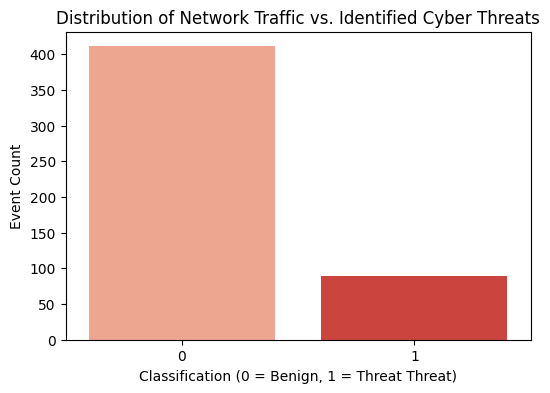

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Print text summary output
print("--- Cyber Threat Dataset Summary ---")
df = pd.read_csv('event_profiling_data.csv')
print(f"Total Network Events Analyzed: {len(df)}")
print(df.info())

# 2. Generate a visual chart directly inside the notebook cell
plt.figure(figsize=(6, 4))
# (Replace 'Threat' with your actual classification column name if different)
sns.countplot(x='Threat', data=df, palette='Reds')
plt.title('Distribution of Network Traffic vs. Identified Cyber Threats')
plt.xlabel('Classification (0 = Benign, 1 = Threat Threat)')
plt.ylabel('Event Count')
plt.show()